In [32]:
import networkx as nx

# --- 1. 大体3つのコミュニティを狙うLFRグラフの生成 ---
n = 20000

# ※LFRは数学的な制約が厳しいため、エラーが出ないように平均次数なども調整しています
G = nx.LFR_benchmark_graph(
    n=n,
    tau1=2.5,           # 次数分布のべき指数
    tau2=1.5,           # コミュニティサイズのべき指数（小さいほどサイズにばらつきが出る）
    mu=0.1,             # 混合パラメータ（0.1ならコミュニティが明確）
    average_degree=15,   # ノードの平均次数
    min_community=1000,   # 最小のコミュニティサイズ
    max_community=18000,  # 最大のコミュニティサイズ
    seed=10             # シード値（この値を変えると分割のされ方が変わります）
)

# --- 2. 生成された正解データの確認 ---
# 各ノードに割り当てられた 'community' 属性を取得
true_communities = {frozenset(G.nodes[v]['community']) for v in G}

# サイズが大きい順に並び替えて出力
sorted_communities = sorted(true_communities, key=len, reverse=True)

print(f"【LFRが生成した正解】コミュニティ数: {len(sorted_communities)}")
print("-" * 30)
for i, c in enumerate(sorted_communities):
    print(f"  コミュニティ {i+1} のサイズ: {len(c)}")

【LFRが生成した正解】コミュニティ数: 6
------------------------------
  コミュニティ 1 のサイズ: 9114
  コミュニティ 2 のサイズ: 3559
  コミュニティ 3 のサイズ: 3442
  コミュニティ 4 のサイズ: 1591
  コミュニティ 5 のサイズ: 1216
  コミュニティ 6 のサイズ: 1078


In [122]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
n = 5000

# ※LFRは数学的な制約が厳しいため、エラーが出ないように平均次数なども調整しています
G = nx.LFR_benchmark_graph(
    n=n,
    tau1 = 3.0,           # 次数分布の指数
    tau2 = 1.016,        # コミュニティサイズ分布の指数
    mu = 0.8,           # ミキシングパラメータ (小さいほどコミュニティが明確)
    average_degree = 10, # 平均次数
    min_community = 300, # 最小コミュニティサイズ
    max_community = 900,  # 最大のコミュニティサイズ
    seed=90           # シード値（この値を変えると分割のされ方が変わります）
)

# --- 2. 生成された正解データの確認 ---
# 各ノードに割り当てられた 'community' 属性を取得
true_communities = {frozenset(G.nodes[v]['community']) for v in G}

# サイズが大きい順に並び替えて出力
sorted_communities = sorted(true_communities, key=len, reverse=True)

print(f"【LFRが生成した正解】コミュニティ数: {len(sorted_communities)}")
print("-" * 30)
for i, c in enumerate(sorted_communities):
    print(f"  コミュニティ {i+1} のサイズ: {len(c)}")


【LFRが生成した正解】コミュニティ数: 11
------------------------------
  コミュニティ 1 のサイズ: 586
  コミュニティ 2 のサイズ: 508
  コミュニティ 3 のサイズ: 477
  コミュニティ 4 のサイズ: 475
  コミュニティ 5 のサイズ: 475
  コミュニティ 6 のサイズ: 460
  コミュニティ 7 のサイズ: 458
  コミュニティ 8 のサイズ: 414
  コミュニティ 9 のサイズ: 395
  コミュニティ 10 のサイズ: 381
  コミュニティ 11 のサイズ: 371


In [125]:
import networkx as nx
import numpy as np
import pandas as pd
import os

# --- 1. 大体3つのコミュニティを狙うLFRグラフの生成 ---
n = 5000

G = nx.LFR_benchmark_graph(
    n=n,
    tau1 = 3.0,           # 次数分布の指数
    tau2 = 1.016,        # コミュニティサイズ分布の指数
    mu = 0.8,           # ミキシングパラメータ (小さいほどコミュニティが明確)
    average_degree = 10, # 平均次数
    min_community = 300, # 最小コミュニティサイズ
    max_community = 900,  # 最大のコミュニティサイズ
    seed=90              # シード値
)

# --- 2. 生成された正解データの確認 ---
true_communities = {frozenset(G.nodes[v]['community']) for v in G}
sorted_communities = sorted(true_communities, key=len, reverse=True)

print(f"【LFRが生成した正解】コミュニティ数: {len(sorted_communities)}")
print("-" * 30)
for i, c in enumerate(sorted_communities):
    print(f"  コミュニティ {i+1} のサイズ: {len(c)}")


# --- 3. コミュニティごとにJSON隣接行列形式でファイル保存 ---

# 新しく隣接行列JSONを保存する場所 (ご提示のコードに合わせる)
OUT_FOLDER = "LFR11_communities"
os.makedirs(OUT_FOLDER, exist_ok=True)
G_for_save = G.copy()
for n in G_for_save.nodes:
    if 'community' in G_for_save.nodes[n]:
        del G_for_save.nodes[n]['community']
nx.write_graphml(G_for_save, os.path.join(OUT_FOLDER, "LFR_total_graph.graphml"))
print(f"\n✅ 全体グラフを保存しました")


processed_count = 0

for i, c in enumerate(sorted_communities):
    # ファイル名を変更し、拡張子を .txt に統一
    output_filename = f"LFR_community_{i+1}.txt"
    output_path = os.path.join(OUT_FOLDER, output_filename)
    
    # コミュニティ内のノードだけを抽出して部分グラフを作成
    subgraph = G.subgraph(c)
    
    if subgraph.number_of_nodes() == 0:
        print(f"警告: コミュニティ {i+1} はノード数が0のためスキップしました。")
        continue

    try:
        # 2. NetworkXグラフを隣接行列（NumPy配列）に変換
        # ※LFRは無向グラフですが、同様に隣接行列化可能です
        adj = nx.to_numpy_array(subgraph) 
        
        # 3. データ型をint32に変換
        adj = adj.astype(np.int32)
        
        # 4. Pandas DataFrameに変換
        # ノードIDは含まれず、行/列のインデックスが0, 1, 2...となる行列形式
        nodes_list = list(subgraph.nodes)
        df = pd.DataFrame(adj)
        
        # 5. JSON形式でファイルに保存
        # デフォルト(orient='columns')で保存され、インデックスがキーになります。
        df.to_json(output_path) 
        
        print(f"  - 💾 保存成功: {output_filename} ({subgraph.number_of_nodes()}ノード)")
        processed_count += 1

    except Exception as e:
        print(f"  - ❌ 保存失敗: コミュニティ {i+1} - エラー: {e}")

print(f"\n--- 完了 ---")
print(f"合計 {len(sorted_communities)} 件中、{processed_count} 件のコミュニティをJSON隣接行列形式で保存しました。")

【LFRが生成した正解】コミュニティ数: 11
------------------------------
  コミュニティ 1 のサイズ: 586
  コミュニティ 2 のサイズ: 508
  コミュニティ 3 のサイズ: 477
  コミュニティ 4 のサイズ: 475
  コミュニティ 5 のサイズ: 475
  コミュニティ 6 のサイズ: 460
  コミュニティ 7 のサイズ: 458
  コミュニティ 8 のサイズ: 414
  コミュニティ 9 のサイズ: 395
  コミュニティ 10 のサイズ: 381
  コミュニティ 11 のサイズ: 371

✅ 全体グラフを保存しました
  - 💾 保存成功: LFR_community_1.txt (586ノード)
  - 💾 保存成功: LFR_community_2.txt (508ノード)
  - 💾 保存成功: LFR_community_3.txt (477ノード)
  - 💾 保存成功: LFR_community_4.txt (475ノード)
  - 💾 保存成功: LFR_community_5.txt (475ノード)
  - 💾 保存成功: LFR_community_6.txt (460ノード)
  - 💾 保存成功: LFR_community_7.txt (458ノード)
  - 💾 保存成功: LFR_community_8.txt (414ノード)
  - 💾 保存成功: LFR_community_9.txt (395ノード)
  - 💾 保存成功: LFR_community_10.txt (381ノード)
  - 💾 保存成功: LFR_community_11.txt (371ノード)

--- 完了 ---
合計 11 件中、11 件のコミュニティをJSON隣接行列形式で保存しました。


In [78]:
import networkx as nx
import numpy as np
import pandas as pd
import os

# --- 1. 大体3つのコミュニティを狙うLFRグラフの生成 ---
n = 5000

G = nx.LFR_benchmark_graph(
    n=n,
    tau1 = 3.0,           # 次数分布の指数
    tau2 = 1.016,        # コミュニティサイズ分布の指数
    mu = 0.8,           # ミキシングパラメータ (小さいほどコミュニティが明確)
    average_degree = 10, # 平均次数
    min_community = 100, # 最小コミュニティサイズ
    max_community = 1500,  # 最大のコミュニティサイズ
    seed=6              # シード値
)

# --- 2. 生成された正解データの確認 ---
true_communities = {frozenset(G.nodes[v]['community']) for v in G}
sorted_communities = sorted(true_communities, key=len, reverse=True)

print(f"【LFRが生成した正解】コミュニティ数: {len(sorted_communities)}")
print("-" * 30)
for i, c in enumerate(sorted_communities):
    print(f"  コミュニティ {i+1} のサイズ: {len(c)}")


# --- 3. コミュニティごとにJSON隣接行列形式でファイル保存 ---

# 新しく隣接行列JSONを保存する場所 (ご提示のコードに合わせる)
OUT_FOLDER = "LFR10_communities1-2"

# 1. 出力フォルダを作成
os.makedirs(OUT_FOLDER, exist_ok=True)
print(f"\n✅ 出力フォルダを作成しました: {OUT_FOLDER}")

processed_count = 0

for i, c in enumerate(sorted_communities):
    # ファイル名を変更し、拡張子を .txt に統一
    output_filename = f"LFR_community_{i+1}.txt"
    output_path = os.path.join(OUT_FOLDER, output_filename)
    
    # コミュニティ内のノードだけを抽出して部分グラフを作成
    subgraph = G.subgraph(c)
    
    if subgraph.number_of_nodes() == 0:
        print(f"警告: コミュニティ {i+1} はノード数が0のためスキップしました。")
        continue

    try:
        # 2. NetworkXグラフを隣接行列（NumPy配列）に変換
        # ※LFRは無向グラフですが、同様に隣接行列化可能です
        adj = nx.to_numpy_array(subgraph) 
        
        # 3. データ型をint32に変換
        adj = adj.astype(np.int32)
        
        # 4. Pandas DataFrameに変換
        # ノードIDは含まれず、行/列のインデックスが0, 1, 2...となる行列形式
        df = pd.DataFrame(adj)
        
        # 5. JSON形式でファイルに保存
        # デフォルト(orient='columns')で保存され、インデックスがキーになります。
        df.to_json(output_path) 
        
        print(f"  - 💾 保存成功: {output_filename} ({subgraph.number_of_nodes()}ノード)")
        processed_count += 1

    except Exception as e:
        print(f"  - ❌ 保存失敗: コミュニティ {i+1} - エラー: {e}")

print(f"\n--- 完了 ---")
print(f"合計 {len(sorted_communities)} 件中、{processed_count} 件のコミュニティをJSON隣接行列形式で保存しました。")

【LFRが生成した正解】コミュニティ数: 10
------------------------------
  コミュニティ 1 のサイズ: 1159
  コミュニティ 2 のサイズ: 1082
  コミュニティ 3 のサイズ: 960
  コミュニティ 4 のサイズ: 694
  コミュニティ 5 のサイズ: 283
  コミュニティ 6 のサイズ: 224
  コミュニティ 7 のサイズ: 198
  コミュニティ 8 のサイズ: 141
  コミュニティ 9 のサイズ: 131
  コミュニティ 10 のサイズ: 128

✅ 出力フォルダを作成しました: LFR10_communities1-2
  - 💾 保存成功: LFR_community_1.txt (1159ノード)
  - 💾 保存成功: LFR_community_2.txt (1082ノード)
  - 💾 保存成功: LFR_community_3.txt (960ノード)
  - 💾 保存成功: LFR_community_4.txt (694ノード)
  - 💾 保存成功: LFR_community_5.txt (283ノード)
  - 💾 保存成功: LFR_community_6.txt (224ノード)
  - 💾 保存成功: LFR_community_7.txt (198ノード)
  - 💾 保存成功: LFR_community_8.txt (141ノード)
  - 💾 保存成功: LFR_community_9.txt (131ノード)
  - 💾 保存成功: LFR_community_10.txt (128ノード)

--- 完了 ---
合計 10 件中、10 件のコミュニティをJSON隣接行列形式で保存しました。


In [80]:
#全特徴量の計算と保存(ノード/エッジ、密度、平均クラスター係数、スケールフリー性、スモールワールド性、PageRank)
import networkx as nx
import json
import os
import numpy as np
import csv
from glob import glob
import warnings

# 警告（Polyfitの計算時など）を非表示にする
warnings.filterwarnings('ignore')

# ==========================================
# 1. データ読み込み関数
# ==========================================
def convert_json_adj_dict_to_graph(file_path):
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        G = nx.DiGraph()
        for source_node, targets in data.items():
            G.add_node(source_node)
            for target_node, weight in targets.items():
                G.add_node(target_node)
                if weight == 1:
                    G.add_edge(source_node, target_node, weight=weight)
        return G
    except Exception as e:
        print(f"ファイル読み込みエラー ({file_path}): {e}")
        return None

def process_multiple_files(folder_path="directed_communities_txt"):
    file_paths = glob(os.path.join(folder_path, '*.txt'))
    if not file_paths:
        print(f"警告: フォルダ '{folder_path}' 内に .txt ファイルが見つかりませんでした。")
        return []
    
    import re
    def sort_key(filepath):
        numbers = re.findall(r'\d+', os.path.basename(filepath))
        return int(numbers[0]) if numbers else 0
    
    file_paths.sort(key=sort_key)
    
    graphs_list = []
    for file_path in file_paths:
        graph = convert_json_adj_dict_to_graph(file_path)
        if graph:
            graphs_list.append({
                "filename": os.path.basename(file_path),
                "graph": graph,
            })
    return graphs_list

# ==========================================
# 2. 指標を計算する関数（★PageRank比率を追加）
# ==========================================
def analyze_single_community(graph):
    N = graph.number_of_nodes()
    M = graph.number_of_edges()
    
    if N == 0:
        return {"nodes": 0, "edges": 0, "density": 0.0, "clustering": 0.0, "sigma": 0.0, "top_pr": [], "pr_ratios": []}

    density = nx.density(graph) if N >= 2 else 0.0
    clustering = nx.average_clustering(graph)

    # PageRankの計算
    try:
        pagerank_scores = nx.pagerank(graph)
        top_pr = sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)[:3]
    except:
        top_pr = []

    # ★1位に対する2位・3位のスコア比率（類似度）の計算
    pr_ratios = [1.0]  # 1位自身は 1.0 (100%)
    if len(top_pr) >= 1:
        top_1_score = top_pr[0][1]
        for i in range(1, len(top_pr)):
            if top_1_score > 0:
                ratio = top_pr[i][1] / top_1_score
            else:
                ratio = 0.0
            pr_ratios.append(ratio)

    # スモールワールド性 (Sigma)
    sigma = 0.0
    Gu = graph.to_undirected()
    components = sorted(nx.connected_components(Gu), key=len, reverse=True)
    if components:
        lcc = Gu.subgraph(components[0])
        N_lcc = lcc.number_of_nodes()
        M_lcc = lcc.number_of_edges()

        if N_lcc >= 4:
            C = nx.average_clustering(lcc)
            L = nx.average_shortest_path_length(lcc)
            
            p = (2.0 * M_lcc) / (N_lcc * (N_lcc - 1)) if N_lcc > 1 else 0
            C_rand = p
            k_avg = N_lcc * p
            L_rand = np.log(N_lcc) / np.log(k_avg) if k_avg > 1 else L
            
            if C_rand > 0 and L_rand > 0 and L > 0:
                sigma = (C / C_rand) / (L / L_rand)

    return {
        "nodes": N,
        "edges": M,
        "density": density,
        "clustering": clustering,
        "sigma": sigma,
        "top_pr": top_pr,
        "pr_ratios": pr_ratios  # 比率データを格納
    }

# ==========================================
# 3. メイン実行部
# ==========================================
if __name__ == "__main__":
    FOLDER_PATH = "LFR10_communities"
    TXT_OUTPUT_FILE = "LFR10_communities_analysis_report.txt"
    CSV_OUTPUT_FILE = "LFR10_communities_analysis_report.csv"
    
    print("データを読み込み、全コミュニティの指標およびPageRank比率を計算中...\n")
    converted_graphs = process_multiple_files(FOLDER_PATH)
    
    if not converted_graphs:
        print("処理を終了します。")
    else:
        results = []
        for item in converted_graphs:
            analysis = analyze_single_community(item['graph'])
            analysis['filename'] = item['filename']
            results.append(analysis)
            
        # コンソール出力
        print("="*105)
        print(f" {'全コミュニティ分析結果一覧':^90}")
        print("="*105)
        header = f"{'ファイル名':<18} | {'ノード':>5} | {'エッジ':>6} | {'密度':>7} | {'クラスタ':>8} | {'Sigma':>7} | {'PR1位スコア'} | {'2位/1位比率'} | {'3位/1位比率'}"
        print(header)
        print("-" * 105)
        
        for r in results:
            fname = r['filename']
            if len(fname) > 18: fname = fname[:15] + "..."
            
            dens = f"{r['density']:.4f}"
            clus = f"{r['clustering']:.4f}"
            sig = f"{r['sigma']:.2f}"
            
            pr_1_score = f"{r['top_pr'][0][1]:.4f}" if len(r['top_pr']) >= 1 else "N/A"
            ratio_2 = f"{r['pr_ratios'][1]*100:.1f}%" if len(r['pr_ratios']) >= 2 else "N/A"
            ratio_3 = f"{r['pr_ratios'][2]*100:.1f}%" if len(r['pr_ratios']) >= 3 else "N/A"
                
            row_str = f"{fname:<18} | {r['nodes']:>5} | {r['edges']:>6} | {dens:>7} | {clus:>8} | {sig:>7} | {pr_1_score:>10} | {ratio_2:>10} | {ratio_3:>10}"
            print(row_str)
            
        print("="*105)

        # ---------------------------------------------------------
        # 詳細テキストレポートの書き出し（比率の解説つき）
        # ---------------------------------------------------------
        with open(TXT_OUTPUT_FILE, 'w', encoding='utf-8') as f:
            f.write("="*60 + "\n")
            f.write(" 全コミュニティ詳細プロファイル（PageRank格差分析）\n")
            f.write("="*60 + "\n\n")
            
            for r in results:
                f.write(f"📂 ファイル: {r['filename']}\n")
                f.write(f"   ├ 規模感: ノード数 {r['nodes']} / エッジ数 {r['edges']}\n")
                f.write(f"   ├ 密度: {r['density']:.6f}  |  クラスタ係数: {r['clustering']:.6f}  |  Sigma: {r['sigma']:.2f}\n")
                f.write(f"   └ 👑 影響力 (PageRank) 格差分析:\n")
                
                if r['top_pr']:
                    for rank in range(len(r['top_pr'])):
                        node, score = r['top_pr'][rank]
                        ratio = r['pr_ratios'][rank]
                        if rank == 0:
                            f.write(f"      🥇 1位: ノード '{node}' (スコア: {score:.4f}) [基準: 100.0%]\n")
                        else:
                            f.write(f"      {'🥈' if rank==1 else '🥉'} {rank+1}位: ノード '{node}' (スコア: {score:.4f}) [1位の {ratio*100:.1f}% の影響力]\n")
                else:
                    f.write("      データなし\n")
                f.write("-" * 60 + "\n")
                
        print(f"\n✅ 詳細テキストレポートを '{TXT_OUTPUT_FILE}' に保存しました。")

        # ---------------------------------------------------------
        # CSVファイルへのデータ保存（比率カラムを追加）
        # ---------------------------------------------------------
        with open(CSV_OUTPUT_FILE, 'w', newline='', encoding='utf-8-sig') as f:
            writer = csv.writer(f)
            
            header_row = [
                "Filename", "Nodes", "Edges", "Density", "Clustering_Coefficient", "Sigma",
                "PR_1_Node", "PR_1_Score",
                "PR_2_Node", "PR_2_Score", "PR_2_to_PR_1_Ratio(%)",
                "PR_3_Node", "PR_3_Score", "PR_3_to_PR_1_Ratio(%)"
            ]
            writer.writerow(header_row)
            
            for r in results:
                pr_data = []
                # 1位のデータ
                if len(r['top_pr']) >= 1:
                    pr_data.extend([r['top_pr'][0][0], f"{r['top_pr'][0][1]:.6f}"])
                else:
                    pr_data.extend(["N/A", "N/A"])
                
                # 2位・3位のデータ（スコアと対1位比率をセットにする）
                for i in range(1, 3):
                    if i < len(r['top_pr']):
                        node_name, score = r['top_pr'][i]
                        ratio_pct = r['pr_ratios'][i] * 100
                        pr_data.extend([node_name, f"{score:.6f}", f"{ratio_pct:.1f}%"])
                    else:
                        pr_data.extend(["N/A", "N/A", "N/A"])
                
                row = [
                    r['filename'], r['nodes'], r['edges'],
                    f"{r['density']:.6f}", f"{r['clustering']:.6f}", f"{r['sigma']:.4f}"
                ] + pr_data
                
                writer.writerow(row)
                
        print(f"✅ 新カラムを追加したCSVデータを '{CSV_OUTPUT_FILE}' に保存しました。")

データを読み込み、全コミュニティの指標およびPageRank比率を計算中...

                                       全コミュニティ分析結果一覧                                       
ファイル名              |   ノード |    エッジ |      密度 |     クラスタ |   Sigma | PR1位スコア | 2位/1位比率 | 3位/1位比率
---------------------------------------------------------------------------------------------------------
LFR_community_1... |  1159 |    556 |  0.0004 |   0.0012 |    0.84 |     0.0212 |      56.6% |      46.5%
LFR_community_2... |  1082 |   1230 |  0.0011 |   0.0000 |    0.00 |     0.0100 |      86.7% |      75.5%
LFR_community_3... |   960 |   2246 |  0.0024 |   0.0016 |    0.67 |     0.0164 |      79.2% |      44.2%
LFR_community_4... |   694 |    238 |  0.0005 |   0.0000 |    0.00 |     0.0793 |      48.8% |      30.4%
LFR_community_5... |   283 |     10 |  0.0001 |   0.0000 |    0.00 |     0.0196 |     100.0% |     100.0%
LFR_community_6... |   224 |    130 |  0.0026 |   0.0000 |    0.00 |     0.1272 |      24.9% |      23.3%
LFR_community_7... |   198 |

=== γ推定 ===
LFR_community_1.txt: γ=2.702
LFR_community_2.txt: γ=2.970
LFR_community_3.txt: γ=2.743
LFR_community_4.txt: γ=2.882
LFR_community_5.txt: γ=2.775
LFR_community_6.txt: γ=2.645

=== 距離例 ===
Distance(16,21) = 0.000076

=== LFR_community_1.txt に近い順 ===
LFR_community_2.txt: 0.000076
LFR_community_4.txt: 0.000514
LFR_community_3.txt: 0.001573
LFR_community_6.txt: 0.003454
LFR_community_5.txt: 0.005754


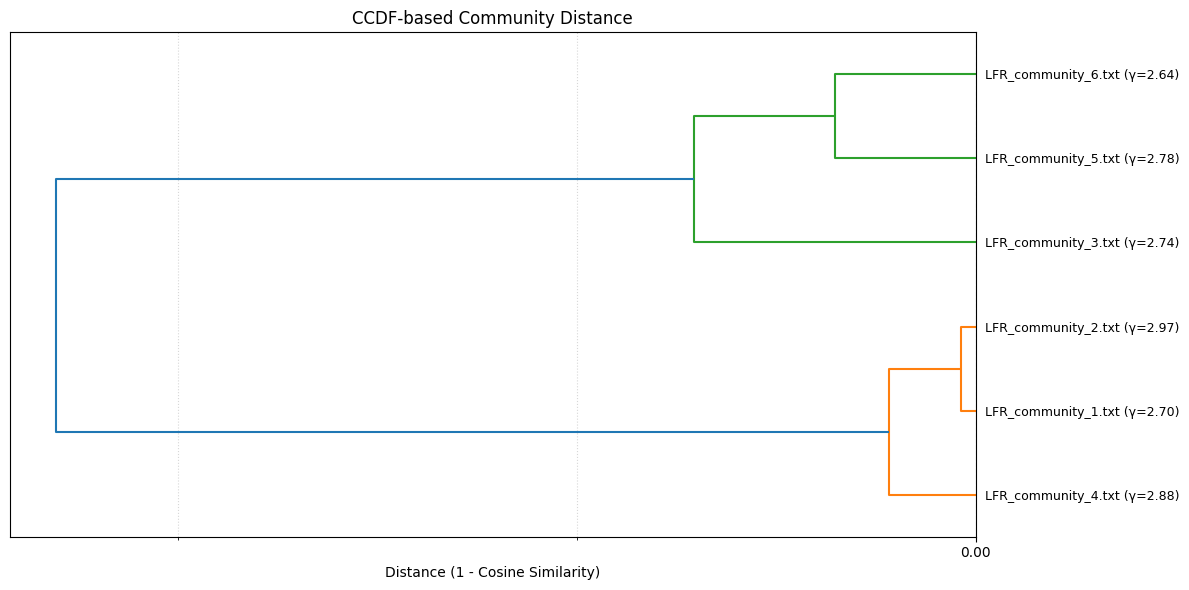

In [5]:
# CCDF/コサイン距離　スケールフリー性
import os
import json
import re
from glob import glob
import numpy as np
import networkx as nx
import powerlaw
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator


# =========================================================
# 1. JSON → グラフ変換
# =========================================================
def convert_json_adj_dict_to_graph(file_path):
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        G = nx.DiGraph()

        for source, targets in data.items():
            G.add_node(source)
            for target, weight in targets.items():
                if weight == 1:
                    G.add_edge(source, target)

        return G

    except Exception as e:
        print(f"[ERROR] {file_path}: {e}")
        return None


# =========================================================
# 2. 複数ファイル読み込み
# =========================================================
def process_multiple_files(folder_path):
    file_paths = glob(os.path.join(folder_path, '*.txt'))

    if not file_paths:
        raise FileNotFoundError("ファイルが見つかりません")

    def sort_key(filepath):
        nums = re.findall(r'\d+', os.path.basename(filepath))
        return int(nums[0]) if nums else 0

    file_paths.sort(key=sort_key)

    graphs = []
    for path in file_paths:
        G = convert_json_adj_dict_to_graph(path)
        if G is not None:
            graphs.append({
                "name": os.path.basename(path),
                "graph": G
            })

    return graphs


# =========================================================
# 3. CCDF計算
# =========================================================
def compute_ccdf(degrees, N_hat):
    counts = np.bincount(degrees, minlength=N_hat)
    prob = counts / len(degrees)
    ccdf = np.flip(np.cumsum(np.flip(prob)))
    return ccdf


# =========================================================
# 4. コサイン距離
# =========================================================
def cosine_distance(v1, v2):
    if np.all(v1 == 0) or np.all(v2 == 0):
        return 1.0
    cos_sim = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    return 1.0 - cos_sim


# =========================================================
# 5. 距離取得関数
# =========================================================
def get_distance(comm1, comm2, comm_names, distance_matrix):
    if comm1 not in comm_names:
        raise ValueError(f"{comm1} が存在しません")
    if comm2 not in comm_names:
        raise ValueError(f"{comm2} が存在しません")

    i = comm_names.index(comm1)
    j = comm_names.index(comm2)
    return distance_matrix[i, j]


# =========================================================
# 6. メイン処理
# =========================================================
if __name__ == "__main__":

    folder = "LFR_communities"
    data = process_multiple_files(folder)

    all_degrees = {}
    gamma_vals = {}
    max_degree = 0

    print("=== γ推定 ===")

    for item in data:
        name = item["name"]
        G = item["graph"]

        degrees = [d for _, d in G.in_degree()]

        if len(degrees) == 0:
            continue

        all_degrees[name] = degrees
        max_degree = max(max_degree, max(degrees))

        try:
            fit = powerlaw.Fit(degrees, discrete=True, verbose=False)
            gamma_vals[name] = fit.alpha
            print(f"{name}: γ={fit.alpha:.3f}")
        except:
            gamma_vals[name] = None
            print(f"{name}: γ=N/A")

    # =====================================================
    # CCDFベクトル
    # =====================================================
    N_hat = max_degree + 1
    comm_names = list(all_degrees.keys())

    ccdf_vectors = {}
    for name, deg in all_degrees.items():
        ccdf_vectors[name] = compute_ccdf(deg, N_hat)

    # =====================================================
    # 距離行列
    # =====================================================
    n = len(comm_names)
    distance_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            v1 = ccdf_vectors[comm_names[i]]
            v2 = ccdf_vectors[comm_names[j]]
            distance_matrix[i, j] = cosine_distance(v1, v2)
    
    np.fill_diagonal(distance_matrix, 0.0)

    # =====================================================
    # 距離確認（例）
    # =====================================================
    print("\n=== 距離例 ===")
    try:
        d = get_distance("LFR_community_1.txt", "LFR_community_2.txt", comm_names, distance_matrix)
        print(f"Distance(16,21) = {d:.6f}")
    except Exception as e:
        print(e)

    # =====================================================
    # 近い順ランキング（例）
    # =====================================================
    target = comm_names[0]
    print(f"\n=== {target} に近い順 ===")

    idx = comm_names.index(target)
    dist_list = []

    for i, name in enumerate(comm_names):
        if i != idx:
            dist_list.append((name, distance_matrix[idx, i]))

    dist_list.sort(key=lambda x: x[1])

    for name, d in dist_list:
        print(f"{name}: {d:.6f}")

    # =====================================================
    # 階層クラスタリング
    # =====================================================
    condensed = squareform(distance_matrix)
    Z = sch.linkage(condensed, method='average')

    # ラベル
    labels = []
    for name in comm_names:
        if gamma_vals[name] is not None:
            labels.append(f"{name} (γ={gamma_vals[name]:.2f})")
        else:
            labels.append(f"{name} (γ=N/A)")

    # =====================================================
    # デンドログラム
    # =====================================================
    fig, ax = plt.subplots(figsize=(12, max(6, n * 0.35)))

    sch.dendrogram(
        Z,
        labels=labels,
        orientation='left',
        leaf_font_size=9,
        ax=ax
    )

    ax.xaxis.set_major_locator(MultipleLocator(0.01))
    ax.xaxis.set_minor_locator(MultipleLocator(0.002))

    ax.grid(axis='x', which='major', linestyle='--', alpha=0.7)
    ax.grid(axis='x', which='minor', linestyle=':', alpha=0.5)

    plt.title("CCDF-based Community Distance")
    plt.xlabel("Distance (1 - Cosine Similarity)")
    plt.tight_layout()
    plt.show()

✅ 'LFR_communities_analysis_report.csv' を正常に読み込みました。データ件数: 6 件


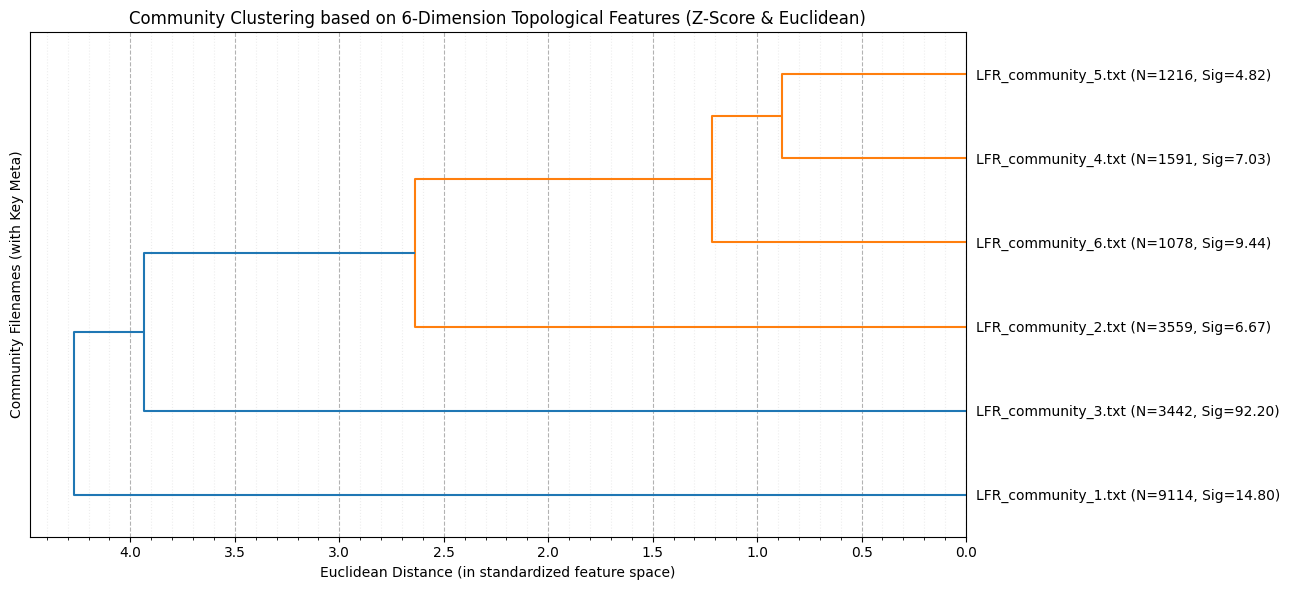


=== 正規化前の各特徴量の基本統計量（スケール確認用） ===
            Nodes     Edges   Density  Clustering_Coefficient      Sigma  \
mean  3333.333333   50315.0  0.007268                0.093865  22.492283   
min   1078.000000   15127.0  0.001687                0.022550   4.820600   
max   9114.000000  140124.0  0.013060                0.280477  92.199300   

      PR_2_to_PR_1_Ratio_Num  
mean                0.703833  
min                 0.374000  
max                 0.955000  


In [3]:
#各特徴量の基本統計量を正規化し、ユークリッド距離の計算 ＆ 階層クラスタリング
import pandas as pd
import numpy as np
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# =========================================================================
# 1. データの読み込みと前処理
# =========================================================================
csv_file = "LFR_communities_analysis_report.csv"

try:
    df = pd.read_csv(csv_file)
    print(f"✅ '{csv_file}' を正常に読み込みました。データ件数: {len(df)} 件")
except Exception as e:
    print(f"❌ CSVファイルの読み込みに失敗しました: {e}")
    exit()

# パーセント表記（例: "57.1%"）の文字列を数値（0.571）に変換する関数
def clean_ratio(val):
    if pd.isna(val) or val == "N/A":
        return 0.0
    if isinstance(val, str) and "%" in val:
        return float(val.replace("%", "")) / 100.0
    return float(val)

# PageRank比率カラムのクレンジング
df['PR_2_to_PR_1_Ratio_Num'] = df['PR_2_to_PR_1_Ratio(%)'].apply(clean_ratio)
df['PR_3_to_PR_1_Ratio_Num'] = df['PR_3_to_PR_1_Ratio(%)'].apply(clean_ratio)

# =========================================================================
# 2. 総合特徴量ベクトルの作成と Zスコア正規化（標準化）
# =========================================================================
# 類似度計算に用いる6つのコア指標（特徴量）を指定
features = [
    'Nodes', 
    'Edges', 
    'Density', 
    'Clustering_Coefficient', 
    'Sigma', 
    'PR_2_to_PR_1_Ratio_Num'
]

X = df[features].copy()

# Zスコア正規化 (平均0, 標準偏差1) を手動で計算（scikit-learn不要）
# 単位の異なる「ノード数」や「密度」を等価に扱うために必須の処理
X_scaled = (X - X.mean()) / X.std()

# 万が一、分散0の項目（すべて同じ値など）があってNaNになった場合の補正
X_scaled = X_scaled.fillna(0.0)

# =========================================================================
# 3. ユークリッド距離の計算 ＆ 階層クラスタリング（群平均法）
# =========================================================================
# クラスタリング用のラベル（例: "0.txt (N=170, Sig=3.74)"）を作成
plot_labels = []
for idx, row in df.iterrows():
    label = f"{row['Filename']} (N={int(row['Nodes'])}, Sig={row['Sigma']:.2f})"
    plot_labels.append(label)

# 🚀 ユークリッド距離 (Euclidean Distance) の計算
# 各指標の「絶対値の距離」を多次元空間上で測定
distance_vector = pdist(X_scaled, metric='euclidean')

# 階層クラスタリングの実行（群平均法: average）
Z = sch.linkage(distance_vector, method='average')

# =========================================================================
# 4. デンドログラムの描画（詳細スケール版）
# =========================================================================
num_comm = len(df)
fig, ax = plt.subplots(figsize=(13, max(6, num_comm * 0.35)))

# 樹状図のプロット
dendro = sch.dendrogram(
    Z,
    labels=plot_labels,
    orientation='left',
    leaf_font_size=10,
    ax=ax
)

# 💡 ユークリッド距離の特性に合わせて目盛りを最適化
# Zスコア空間での距離になるため、通常は 0.5刻み・0.1刻みなどで制御します
ax.xaxis.set_major_locator(MultipleLocator(0.5))  # 主目盛りを0.5刻みに
ax.xaxis.set_minor_locator(MultipleLocator(0.1))  # 補助目盛りを0.1刻みに

# グリッド線の描画（距離を正確に読み取るため）
ax.grid(axis='x', which='major', color='gray', linestyle='--', alpha=0.6)
ax.grid(axis='x', which='minor', color='lightgray', linestyle=':', alpha=0.4)

plt.title("Community Clustering based on 6-Dimension Topological Features (Z-Score & Euclidean)", fontsize=12)
plt.xlabel("Euclidean Distance (in standardized feature space)")
plt.ylabel("Community Filenames (with Key Meta)")
plt.tight_layout()
plt.show()

# =========================================================================
# 5. 【参考】各指標がどれくらいクラスタリングに効いているかの確認用出力
# =========================================================================
print("\n=== 正規化前の各特徴量の基本統計量（スケール確認用） ===")
print(X.describe().loc[['mean', 'min', 'max']])

In [ ]:
#ノードのコミュニティ所属割合を算出
import networkx as nx

def analyze_node_membership(G, target_node):
    """
    指定したノードが、どのコミュニティにどれくらいの割合で属しているか（接続しているか）を計算する
    """
    # ターゲットノードの全つながり（隣接ノード）を取得
    neighbors = list(G.neighbors(target_node))
    total_edges = len(neighbors)
    
    if total_edges == 0:
        return "このノードは誰ともつながっていません。"

    # 各コミュニティへの接続数をカウント
    community_counts = {}
    for neighbor in neighbors:
        # 隣接ノードが所属するコミュニティIDを取得
        comm_id = G.nodes[neighbor]['community_id']
        community_counts[comm_id] = community_counts.get(comm_id, 0) + 1

    # 結果をパーセンテージに変換して整理
    print(f"--- ノード {target_node} の所属割合（全 {total_edges} つながり） ---")
    
    # 割合が高い順に並び替え
    sorted_counts = sorted(community_counts.items(), key=lambda x: x[1], reverse=True)
    
    membership = {}
    for comm_id, count in sorted_counts:
        percentage = (count / total_edges) * 100
        membership[comm_id] = percentage
        print(f"  コミュニティ {comm_id}: {percentage:.1f}% ({count} 本のエッジ)")
        
    return membership

# ==========================================
# 使い方（テスト実行）
# ==========================================

# ※ G はすでに生成・読み込み済みのグラフとします
# 例として、最もつながりが多い「最強のインフルエンサーノード」を特定して分析してみます
degrees = dict(G.degree())
top_influencer = max(degrees, key=degrees.get)

# インフルエンサーノードの所属割合を分析
analyze_node_membership(G, top_influencer)

# ランダムな一般ノード（例えばノード番号 '10'）の所属割合を分析
# analyze_node_membership(G, '10')

In [ ]:
#SBMネットワークの生成とコミュニティ確認
import networkx as nx

print("2万ノードのSBMネットワークを生成しています...")

# 1. コミュニティのサイズを厳密に指定 (合計20,000ノード)
sizes = [10000, 6000, 4000]

# 2. 接続確率の行列 (コミュニティ内の密度を高く、コミュニティ間を低く設定)
# 数値は2万ノード向けに極めて小さく設定しています（大きくするとPCがフリーズします）
probs = [
    [0.0010, 0.0001, 0.0001],  # コミュニティ0 (サイズ10000) の接続確率
    [0.0001, 0.0015, 0.0001],  # コミュニティ1 (サイズ6000)
    [0.0001, 0.0001, 0.0020]   # コミュニティ2 (サイズ4000)
]

# 3. グラフの生成
G = nx.stochastic_block_model(sizes, probs, seed=42)

# SBMでは、各ノードに 'block' という属性でコミュニティIDが保存されます
communities = {0: [], 1: [], 2: []}
for node, data in G.nodes(data=True):
    communities[data['block']].append(node)

print("生成完了！")
print(f"コミュニティ0のサイズ: {len(communities[0])}")
print(f"コミュニティ1のサイズ: {len(communities[1])}")
print(f"コミュニティ2のサイズ: {len(communities[2])}")

2万ノードのSBMネットワークを生成しています...
生成完了！
コミュニティ0のサイズ: 10000
コミュニティ1のサイズ: 6000
コミュニティ2のサイズ: 4000


In [64]:
import networkx as nx

n = 20000

try:
    print("緩和されたLFRネットワークを生成しています...")
    G = nx.LFR_benchmark_graph(
        n=n,
        tau1=3.0,           # 変更：2.5 -> 3.0 (次数の極端なばらつきを少し抑え、計算を安定させる)
        tau2=1.5,
        mu=0.1,
        average_degree=10,  # 変更：15 -> 10 (エッジ数を減らして生成しやすくする)
        max_degree=1000,    # 追加：最大次数を明示的に制限することでエラーを回避
        min_community=2000, # 変更：4000 -> 1000 (小さいコミュニティの存在を許容する)
        max_community=7000,# 変更：12000 -> 10000
        seed=6,
        max_iters=5000      # 追加：内部計算の諦め時間を少し長くする
    )
    print("生成成功！")

 # 1. 各ノードに割り当てられた 'community' 属性を取得し、サイズ順に並び替え
    true_communities = {frozenset(G.nodes[v]['community']) for v in G}
    sorted_communities = sorted(true_communities, key=len, reverse=True)

    print(f"【LFRが生成した正解】コミュニティ数: {len(sorted_communities)}")
    print("-" * 30)
    for i, c in enumerate(sorted_communities):
        print(f"  コミュニティ {i+1} のサイズ: {len(c)}")

except nx.NetworkXError as e:
    print(f"エラー発生: {e}")

緩和されたLFRネットワークを生成しています...
生成成功！
【LFRが生成した正解】コミュニティ数: 5
------------------------------
  コミュニティ 1 のサイズ: 6755
  コミュニティ 2 のサイズ: 4273
  コミュニティ 3 のサイズ: 3487
  コミュニティ 4 のサイズ: 2931
  コミュニティ 5 のサイズ: 2554


In [47]:
import networkx as nx
import numpy as np
import pandas as pd
import os

n = 20000
OUT_FOLDER = "LFR4_communities_1"

try:
    print("緩和されたLFRネットワークを生成しています...")
    G = nx.LFR_benchmark_graph(
        n=n,
        tau1=3.0,           # 変更：2.5 -> 3.0 (次数の極端なばらつきを少し抑え、計算を安定させる)
        tau2=1.5,
        mu=0.1,
        average_degree=10,  # 変更：15 -> 10 (エッジ数を減らして生成しやすくする)
        max_degree=1000,    # 追加：最大次数を明示的に制限することでエラーを回避
        min_community=3000, # 変更：4000 -> 1000 (小さいコミュニティの存在を許容する)
        max_community=8000,# 変更：12000 -> 10000
        seed=63,
        max_iters=5000      # 追加：内部計算の諦め時間を少し長くする
    )
    print("✅ 生成成功！\n")
    
    # --- ここから保存の処理 ---
    
    # 1. 各ノードに割り当てられた 'community' 属性を取得し、サイズ順に並び替え
    true_communities = {frozenset(G.nodes[v]['community']) for v in G}
    sorted_communities = sorted(true_communities, key=len, reverse=True)

    print(f"【LFRが生成した正解】コミュニティ数: {len(sorted_communities)}")
    print("-" * 30)
    for i, c in enumerate(sorted_communities):
        print(f"  コミュニティ {i+1} のサイズ: {len(c)}")

    # 2. 出力フォルダを作成
    os.makedirs(OUT_FOLDER, exist_ok=True)
    print(f"\n📁 出力フォルダを準備しました: {OUT_FOLDER}")

    processed_count = 0

    # 3. 各コミュニティを隣接行列に変換して保存
    for i, c in enumerate(sorted_communities):
        output_filename = f"LFR3_community_{i+1}.txt"
        output_path = os.path.join(OUT_FOLDER, output_filename)
        
        # コミュニティ内の部分グラフを抽出
        subgraph = G.subgraph(c)
        
        if subgraph.number_of_nodes() == 0:
            print(f"警告: コミュニティ {i+1} はノード数が0のためスキップしました。")
            continue

        try:
            # NetworkXグラフを隣接行列（NumPy配列）に変換
            adj = nx.to_numpy_array(subgraph) 
            
            # データ型をint32に変換
            adj = adj.astype(np.int32)
            
            # Pandas DataFrameに変換
            df = pd.DataFrame(adj)
            
            # JSON形式でファイルに保存 (インデックスとカラムがキーの形式)
            df.to_json(output_path) 
            
            print(f"  - 💾 保存成功: {output_filename} ({subgraph.number_of_nodes()}ノード)")
            processed_count += 1

        except Exception as e:
            print(f"  - ❌ 保存失敗: コミュニティ {i+1} - エラー: {e}")

    print(f"\n--- 完了 ---")
    print(f"合計 {len(sorted_communities)} 件中、{processed_count} 件のコミュニティをJSON隣接行列形式で保存しました。")

except nx.NetworkXError as e:
    print(f"❌ エラー発生: {e}")
except Exception as e:
    print(f"❌ 予期せぬエラーが発生しました: {e}")

緩和されたLFRネットワークを生成しています...
✅ 生成成功！

【LFRが生成した正解】コミュニティ数: 4
------------------------------
  コミュニティ 1 のサイズ: 5559
  コミュニティ 2 のサイズ: 5307
  コミュニティ 3 のサイズ: 4787
  コミュニティ 4 のサイズ: 4347

📁 出力フォルダを準備しました: LFR4_communities_1
  - 💾 保存成功: LFR3_community_1.txt (5559ノード)


KeyboardInterrupt: 

In [65]:
#全特徴量の計算と保存(ノード/エッジ、密度、平均クラスター係数、スケールフリー性、スモールワールド性、PageRank)
import networkx as nx
import json
import os
import numpy as np
import csv
from glob import glob
import warnings

# 警告（Polyfitの計算時など）を非表示にする
warnings.filterwarnings('ignore')

# ==========================================
# 1. データ読み込み関数
# ==========================================
def convert_json_adj_dict_to_graph(file_path):
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        G = nx.DiGraph()
        for source_node, targets in data.items():
            G.add_node(source_node)
            for target_node, weight in targets.items():
                G.add_node(target_node)
                if weight == 1:
                    G.add_edge(source_node, target_node, weight=weight)
        return G
    except Exception as e:
        print(f"ファイル読み込みエラー ({file_path}): {e}")
        return None

def process_multiple_files(folder_path="directed_communities_txt"):
    file_paths = glob(os.path.join(folder_path, '*.txt'))
    if not file_paths:
        print(f"警告: フォルダ '{folder_path}' 内に .txt ファイルが見つかりませんでした。")
        return []
    
    import re
    def sort_key(filepath):
        numbers = re.findall(r'\d+', os.path.basename(filepath))
        return int(numbers[0]) if numbers else 0
    
    file_paths.sort(key=sort_key)
    
    graphs_list = []
    for file_path in file_paths:
        graph = convert_json_adj_dict_to_graph(file_path)
        if graph:
            graphs_list.append({
                "filename": os.path.basename(file_path),
                "graph": graph,
            })
    return graphs_list

# ==========================================
# 2. 指標を計算する関数（★PageRank比率を追加）
# ==========================================
def analyze_single_community(graph):
    N = graph.number_of_nodes()
    M = graph.number_of_edges()
    
    if N == 0:
        return {"nodes": 0, "edges": 0, "density": 0.0, "clustering": 0.0, "sigma": 0.0, "top_pr": [], "pr_ratios": []}

    density = nx.density(graph) if N >= 2 else 0.0
    clustering = nx.average_clustering(graph)

    # PageRankの計算
    try:
        pagerank_scores = nx.pagerank(graph)
        top_pr = sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)[:3]
    except:
        top_pr = []

    # ★1位に対する2位・3位のスコア比率（類似度）の計算
    pr_ratios = [1.0]  # 1位自身は 1.0 (100%)
    if len(top_pr) >= 1:
        top_1_score = top_pr[0][1]
        for i in range(1, len(top_pr)):
            if top_1_score > 0:
                ratio = top_pr[i][1] / top_1_score
            else:
                ratio = 0.0
            pr_ratios.append(ratio)

    # スモールワールド性 (Sigma)
    sigma = 0.0
    Gu = graph.to_undirected()
    components = sorted(nx.connected_components(Gu), key=len, reverse=True)
    if components:
        lcc = Gu.subgraph(components[0])
        N_lcc = lcc.number_of_nodes()
        M_lcc = lcc.number_of_edges()

        if N_lcc >= 4:
            C = nx.average_clustering(lcc)
            L = nx.average_shortest_path_length(lcc)
            
            p = (2.0 * M_lcc) / (N_lcc * (N_lcc - 1)) if N_lcc > 1 else 0
            C_rand = p
            k_avg = N_lcc * p
            L_rand = np.log(N_lcc) / np.log(k_avg) if k_avg > 1 else L
            
            if C_rand > 0 and L_rand > 0 and L > 0:
                sigma = (C / C_rand) / (L / L_rand)

    return {
        "nodes": N,
        "edges": M,
        "density": density,
        "clustering": clustering,
        "sigma": sigma,
        "top_pr": top_pr,
        "pr_ratios": pr_ratios  # 比率データを格納
    }

# ==========================================
# 3. メイン実行部
# ==========================================
if __name__ == "__main__":
    FOLDER_PATH = "LFR3_communities_2"
    TXT_OUTPUT_FILE = "LFR3_communities_analysis_report2.txt"
    CSV_OUTPUT_FILE = "LFR3_communities_analysis_report2.csv"
    
    print("データを読み込み、全コミュニティの指標およびPageRank比率を計算中...\n")
    converted_graphs = process_multiple_files(FOLDER_PATH)
    
    if not converted_graphs:
        print("処理を終了します。")
    else:
        results = []
        for item in converted_graphs:
            analysis = analyze_single_community(item['graph'])
            analysis['filename'] = item['filename']
            results.append(analysis)
            
        # コンソール出力
        print("="*105)
        print(f" {'全コミュニティ分析結果一覧':^90}")
        print("="*105)
        header = f"{'ファイル名':<18} | {'ノード':>5} | {'エッジ':>6} | {'密度':>7} | {'クラスタ':>8} | {'Sigma':>7} | {'PR1位スコア'} | {'2位/1位比率'} | {'3位/1位比率'}"
        print(header)
        print("-" * 105)
        
        for r in results:
            fname = r['filename']
            if len(fname) > 18: fname = fname[:15] + "..."
            
            dens = f"{r['density']:.4f}"
            clus = f"{r['clustering']:.4f}"
            sig = f"{r['sigma']:.2f}"
            
            pr_1_score = f"{r['top_pr'][0][1]:.4f}" if len(r['top_pr']) >= 1 else "N/A"
            ratio_2 = f"{r['pr_ratios'][1]*100:.1f}%" if len(r['pr_ratios']) >= 2 else "N/A"
            ratio_3 = f"{r['pr_ratios'][2]*100:.1f}%" if len(r['pr_ratios']) >= 3 else "N/A"
                
            row_str = f"{fname:<18} | {r['nodes']:>5} | {r['edges']:>6} | {dens:>7} | {clus:>8} | {sig:>7} | {pr_1_score:>10} | {ratio_2:>10} | {ratio_3:>10}"
            print(row_str)
            
        print("="*105)

        # ---------------------------------------------------------
        # 詳細テキストレポートの書き出し（比率の解説つき）
        # ---------------------------------------------------------
        with open(TXT_OUTPUT_FILE, 'w', encoding='utf-8') as f:
            f.write("="*60 + "\n")
            f.write(" 全コミュニティ詳細プロファイル（PageRank格差分析）\n")
            f.write("="*60 + "\n\n")
            
            for r in results:
                f.write(f"📂 ファイル: {r['filename']}\n")
                f.write(f"   ├ 規模感: ノード数 {r['nodes']} / エッジ数 {r['edges']}\n")
                f.write(f"   ├ 密度: {r['density']:.6f}  |  クラスタ係数: {r['clustering']:.6f}  |  Sigma: {r['sigma']:.2f}\n")
                f.write(f"   └ 👑 影響力 (PageRank) 格差分析:\n")
                
                if r['top_pr']:
                    for rank in range(len(r['top_pr'])):
                        node, score = r['top_pr'][rank]
                        ratio = r['pr_ratios'][rank]
                        if rank == 0:
                            f.write(f"      🥇 1位: ノード '{node}' (スコア: {score:.4f}) [基準: 100.0%]\n")
                        else:
                            f.write(f"      {'🥈' if rank==1 else '🥉'} {rank+1}位: ノード '{node}' (スコア: {score:.4f}) [1位の {ratio*100:.1f}% の影響力]\n")
                else:
                    f.write("      データなし\n")
                f.write("-" * 60 + "\n")
                
        print(f"\n✅ 詳細テキストレポートを '{TXT_OUTPUT_FILE}' に保存しました。")

        # ---------------------------------------------------------
        # CSVファイルへのデータ保存（比率カラムを追加）
        # ---------------------------------------------------------
        with open(CSV_OUTPUT_FILE, 'w', newline='', encoding='utf-8-sig') as f:
            writer = csv.writer(f)
            
            header_row = [
                "Filename", "Nodes", "Edges", "Density", "Clustering_Coefficient", "Sigma",
                "PR_1_Node", "PR_1_Score",
                "PR_2_Node", "PR_2_Score", "PR_2_to_PR_1_Ratio(%)",
                "PR_3_Node", "PR_3_Score", "PR_3_to_PR_1_Ratio(%)"
            ]
            writer.writerow(header_row)
            
            for r in results:
                pr_data = []
                # 1位のデータ
                if len(r['top_pr']) >= 1:
                    pr_data.extend([r['top_pr'][0][0], f"{r['top_pr'][0][1]:.6f}"])
                else:
                    pr_data.extend(["N/A", "N/A"])
                
                # 2位・3位のデータ（スコアと対1位比率をセットにする）
                for i in range(1, 3):
                    if i < len(r['top_pr']):
                        node_name, score = r['top_pr'][i]
                        ratio_pct = r['pr_ratios'][i] * 100
                        pr_data.extend([node_name, f"{score:.6f}", f"{ratio_pct:.1f}%"])
                    else:
                        pr_data.extend(["N/A", "N/A", "N/A"])
                
                row = [
                    r['filename'], r['nodes'], r['edges'],
                    f"{r['density']:.6f}", f"{r['clustering']:.6f}", f"{r['sigma']:.4f}"
                ] + pr_data
                
                writer.writerow(row)
                
        print(f"✅ 新カラムを追加したCSVデータを '{CSV_OUTPUT_FILE}' に保存しました。")

データを読み込み、全コミュニティの指標およびPageRank比率を計算中...

                                       全コミュニティ分析結果一覧                                       
ファイル名              |   ノード |    エッジ |      密度 |     クラスタ |   Sigma | PR1位スコア | 2位/1位比率 | 3位/1位比率
---------------------------------------------------------------------------------------------------------
LFR3_community_... |  7694 |  71399 |  0.0012 |   0.0057 |    5.00 |     0.0071 |      48.5% |      34.8%
LFR3_community_... |  4971 |  48710 |  0.0020 |   0.0117 |    6.32 |     0.0107 |      70.5% |      47.0%
LFR3_community_... |  7335 |  74841 |  0.0014 |   0.0040 |    2.89 |     0.0034 |      89.6% |      74.7%

✅ 詳細テキストレポートを 'LFR3_communities_analysis_report2.txt' に保存しました。
✅ 新カラムを追加したCSVデータを 'LFR3_communities_analysis_report2.csv' に保存しました。


=== γ推定 ===
LFR3_community_1.txt: γ=2.896
LFR3_community_3.txt: γ=2.694
LFR3_community_2.txt: γ=2.765

=== 距離例 ===
LFR_community_1.txt が存在しません

=== LFR3_community_1.txt に近い順 ===
LFR3_community_3.txt: 0.000697
LFR3_community_2.txt: 0.003507


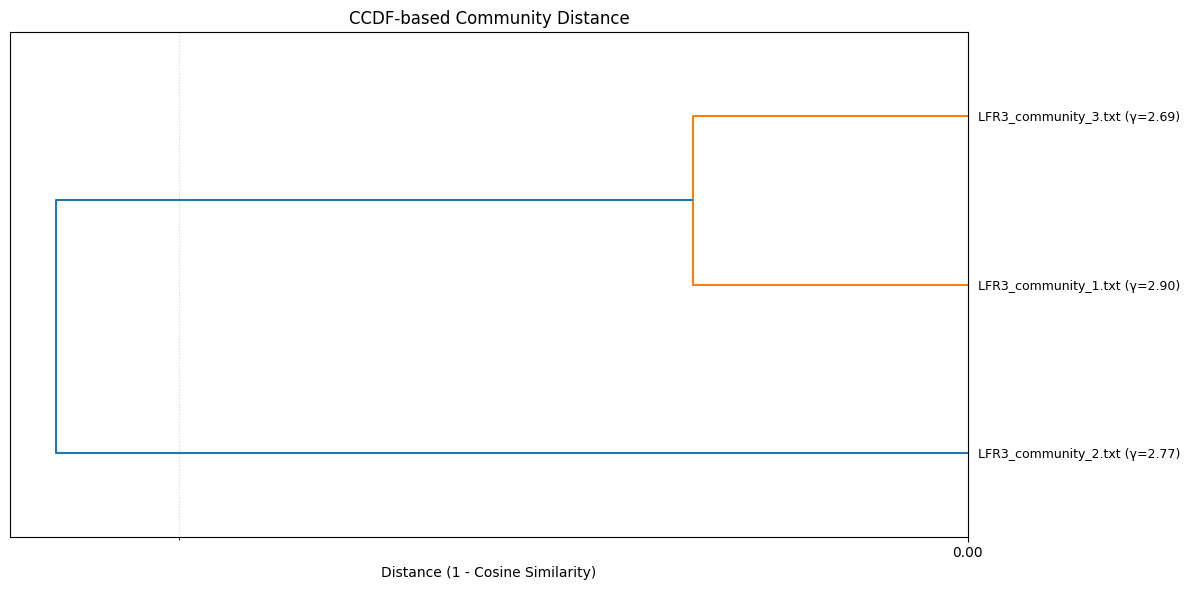

In [66]:
# CCDF/コサイン距離　スケールフリー性
import os
import json
import re
from glob import glob
import numpy as np
import networkx as nx
import powerlaw
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator


# =========================================================
# 1. JSON → グラフ変換
# =========================================================
def convert_json_adj_dict_to_graph(file_path):
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        G = nx.DiGraph()

        for source, targets in data.items():
            G.add_node(source)
            for target, weight in targets.items():
                if weight == 1:
                    G.add_edge(source, target)

        return G

    except Exception as e:
        print(f"[ERROR] {file_path}: {e}")
        return None


# =========================================================
# 2. 複数ファイル読み込み
# =========================================================
def process_multiple_files(folder_path):
    file_paths = glob(os.path.join(folder_path, '*.txt'))

    if not file_paths:
        raise FileNotFoundError("ファイルが見つかりません")

    def sort_key(filepath):
        nums = re.findall(r'\d+', os.path.basename(filepath))
        return int(nums[0]) if nums else 0

    file_paths.sort(key=sort_key)

    graphs = []
    for path in file_paths:
        G = convert_json_adj_dict_to_graph(path)
        if G is not None:
            graphs.append({
                "name": os.path.basename(path),
                "graph": G
            })

    return graphs


# =========================================================
# 3. CCDF計算
# =========================================================
def compute_ccdf(degrees, N_hat):
    counts = np.bincount(degrees, minlength=N_hat)
    prob = counts / len(degrees)
    ccdf = np.flip(np.cumsum(np.flip(prob)))
    return ccdf


# =========================================================
# 4. コサイン距離
# =========================================================
def cosine_distance(v1, v2):
    if np.all(v1 == 0) or np.all(v2 == 0):
        return 1.0
    cos_sim = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    return 1.0 - cos_sim


# =========================================================
# 5. 距離取得関数
# =========================================================
def get_distance(comm1, comm2, comm_names, distance_matrix):
    if comm1 not in comm_names:
        raise ValueError(f"{comm1} が存在しません")
    if comm2 not in comm_names:
        raise ValueError(f"{comm2} が存在しません")

    i = comm_names.index(comm1)
    j = comm_names.index(comm2)
    return distance_matrix[i, j]


# =========================================================
# 6. メイン処理
# =========================================================
if __name__ == "__main__":

    folder = "LFR3_communities_2"
    data = process_multiple_files(folder)

    all_degrees = {}
    gamma_vals = {}
    max_degree = 0

    print("=== γ推定 ===")

    for item in data:
        name = item["name"]
        G = item["graph"]

        degrees = [d for _, d in G.in_degree()]

        if len(degrees) == 0:
            continue

        all_degrees[name] = degrees
        max_degree = max(max_degree, max(degrees))

        try:
            fit = powerlaw.Fit(degrees, discrete=True, verbose=False)
            gamma_vals[name] = fit.alpha
            print(f"{name}: γ={fit.alpha:.3f}")
        except:
            gamma_vals[name] = None
            print(f"{name}: γ=N/A")

    # =====================================================
    # CCDFベクトル
    # =====================================================
    N_hat = max_degree + 1
    comm_names = list(all_degrees.keys())

    ccdf_vectors = {}
    for name, deg in all_degrees.items():
        ccdf_vectors[name] = compute_ccdf(deg, N_hat)

    # =====================================================
    # 距離行列
    # =====================================================
    n = len(comm_names)
    distance_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            v1 = ccdf_vectors[comm_names[i]]
            v2 = ccdf_vectors[comm_names[j]]
            distance_matrix[i, j] = cosine_distance(v1, v2)
    
    np.fill_diagonal(distance_matrix, 0.0)

    # =====================================================
    # 距離確認（例）
    # =====================================================
    print("\n=== 距離例 ===")
    try:
        d = get_distance("LFR_community_1.txt", "LFR_community_2.txt", comm_names, distance_matrix)
        print(f"Distance(16,21) = {d:.6f}")
    except Exception as e:
        print(e)

    # =====================================================
    # 近い順ランキング（例）
    # =====================================================
    target = comm_names[0]
    print(f"\n=== {target} に近い順 ===")

    idx = comm_names.index(target)
    dist_list = []

    for i, name in enumerate(comm_names):
        if i != idx:
            dist_list.append((name, distance_matrix[idx, i]))

    dist_list.sort(key=lambda x: x[1])

    for name, d in dist_list:
        print(f"{name}: {d:.6f}")

    # =====================================================
    # 階層クラスタリング
    # =====================================================
    condensed = squareform(distance_matrix)
    Z = sch.linkage(condensed, method='average')

    # ラベル
    labels = []
    for name in comm_names:
        if gamma_vals[name] is not None:
            labels.append(f"{name} (γ={gamma_vals[name]:.2f})")
        else:
            labels.append(f"{name} (γ=N/A)")

    # =====================================================
    # デンドログラム
    # =====================================================
    fig, ax = plt.subplots(figsize=(12, max(6, n * 0.35)))

    sch.dendrogram(
        Z,
        labels=labels,
        orientation='left',
        leaf_font_size=9,
        ax=ax
    )

    ax.xaxis.set_major_locator(MultipleLocator(0.01))
    ax.xaxis.set_minor_locator(MultipleLocator(0.002))

    ax.grid(axis='x', which='major', linestyle='--', alpha=0.7)
    ax.grid(axis='x', which='minor', linestyle=':', alpha=0.5)

    plt.title("CCDF-based Community Distance")
    plt.xlabel("Distance (1 - Cosine Similarity)")
    plt.tight_layout()
    plt.show()

✅ 'LFR3_communities_analysis_report.csv' を正常に読み込みました。データ件数: 3 件


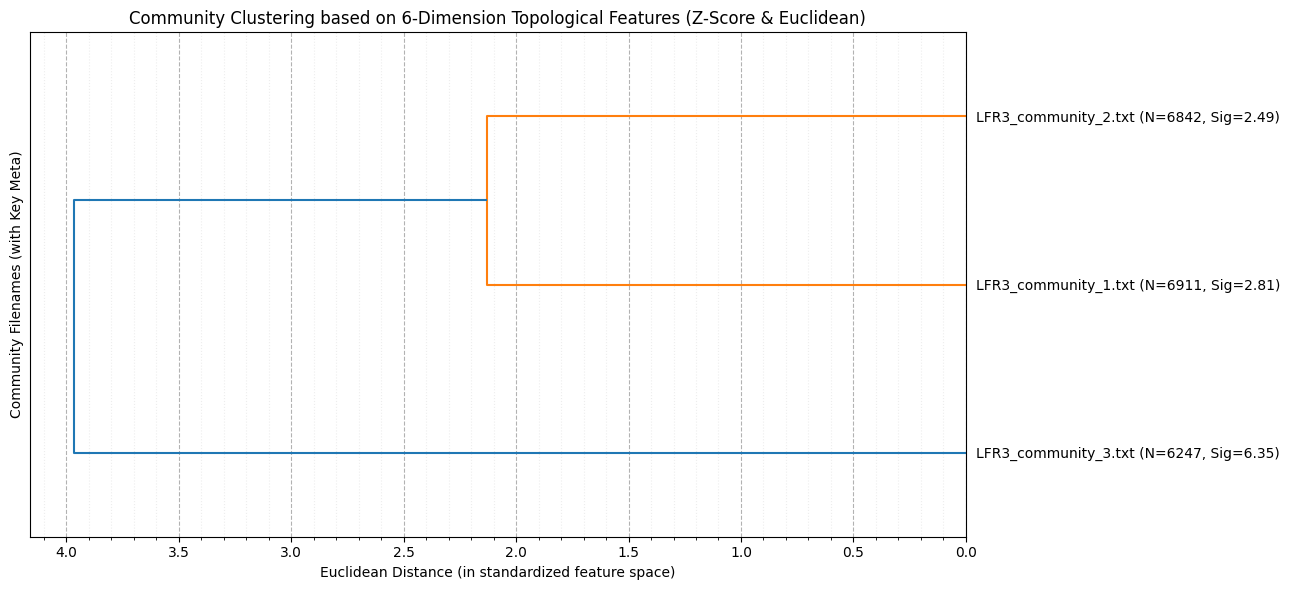


=== 正規化前の各特徴量の基本統計量（スケール確認用） ===
            Nodes    Edges   Density  Clustering_Coefficient   Sigma  \
mean  6666.666667  64448.0  0.001456                0.005550  3.8835   
min   6247.000000  61896.0  0.001311                0.003597  2.4920   
max   6911.000000  68835.0  0.001586                0.009396  6.3509   

      PR_2_to_PR_1_Ratio_Num  
mean                   0.749  
min                    0.586  
max                    0.882  


In [18]:
#各特徴量の基本統計量を正規化し、ユークリッド距離の計算 ＆ 階層クラスタリング
import pandas as pd
import numpy as np
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# =========================================================================
# 1. データの読み込みと前処理
# =========================================================================
csv_file = "LFR3_communities_analysis_report.csv"

try:
    df = pd.read_csv(csv_file)
    print(f"✅ '{csv_file}' を正常に読み込みました。データ件数: {len(df)} 件")
except Exception as e:
    print(f"❌ CSVファイルの読み込みに失敗しました: {e}")
    exit()

# パーセント表記（例: "57.1%"）の文字列を数値（0.571）に変換する関数
def clean_ratio(val):
    if pd.isna(val) or val == "N/A":
        return 0.0
    if isinstance(val, str) and "%" in val:
        return float(val.replace("%", "")) / 100.0
    return float(val)

# PageRank比率カラムのクレンジング
df['PR_2_to_PR_1_Ratio_Num'] = df['PR_2_to_PR_1_Ratio(%)'].apply(clean_ratio)
df['PR_3_to_PR_1_Ratio_Num'] = df['PR_3_to_PR_1_Ratio(%)'].apply(clean_ratio)

# =========================================================================
# 2. 総合特徴量ベクトルの作成と Zスコア正規化（標準化）
# =========================================================================
# 類似度計算に用いる6つのコア指標（特徴量）を指定
features = [
    'Nodes', 
    'Edges', 
    'Density', 
    'Clustering_Coefficient', 
    'Sigma', 
    'PR_2_to_PR_1_Ratio_Num'
]

X = df[features].copy()

# Zスコア正規化 (平均0, 標準偏差1) を手動で計算（scikit-learn不要）
# 単位の異なる「ノード数」や「密度」を等価に扱うために必須の処理
X_scaled = (X - X.mean()) / X.std()

# 万が一、分散0の項目（すべて同じ値など）があってNaNになった場合の補正
X_scaled = X_scaled.fillna(0.0)

# =========================================================================
# 3. ユークリッド距離の計算 ＆ 階層クラスタリング（群平均法）
# =========================================================================
# クラスタリング用のラベル（例: "0.txt (N=170, Sig=3.74)"）を作成
plot_labels = []
for idx, row in df.iterrows():
    label = f"{row['Filename']} (N={int(row['Nodes'])}, Sig={row['Sigma']:.2f})"
    plot_labels.append(label)

# 🚀 ユークリッド距離 (Euclidean Distance) の計算
# 各指標の「絶対値の距離」を多次元空間上で測定
distance_vector = pdist(X_scaled, metric='euclidean')

# 階層クラスタリングの実行（群平均法: average）
Z = sch.linkage(distance_vector, method='average')

# =========================================================================
# 4. デンドログラムの描画（詳細スケール版）
# =========================================================================
num_comm = len(df)
fig, ax = plt.subplots(figsize=(13, max(6, num_comm * 0.35)))

# 樹状図のプロット
dendro = sch.dendrogram(
    Z,
    labels=plot_labels,
    orientation='left',
    leaf_font_size=10,
    ax=ax
)

# 💡 ユークリッド距離の特性に合わせて目盛りを最適化
# Zスコア空間での距離になるため、通常は 0.5刻み・0.1刻みなどで制御します
ax.xaxis.set_major_locator(MultipleLocator(0.5))  # 主目盛りを0.5刻みに
ax.xaxis.set_minor_locator(MultipleLocator(0.1))  # 補助目盛りを0.1刻みに

# グリッド線の描画（距離を正確に読み取るため）
ax.grid(axis='x', which='major', color='gray', linestyle='--', alpha=0.6)
ax.grid(axis='x', which='minor', color='lightgray', linestyle=':', alpha=0.4)

plt.title("Community Clustering based on 6-Dimension Topological Features (Z-Score & Euclidean)", fontsize=12)
plt.xlabel("Euclidean Distance (in standardized feature space)")
plt.ylabel("Community Filenames (with Key Meta)")
plt.tight_layout()
plt.show()

# =========================================================================
# 5. 【参考】各指標がどれくらいクラスタリングに効いているかの確認用出力
# =========================================================================
print("\n=== 正規化前の各特徴量の基本統計量（スケール確認用） ===")
print(X.describe().loc[['mean', 'min', 'max']])

In [20]:
#コミュニティ同士が最初に結成したペアと正確なユークリッド距離
import pandas as pd
import numpy as np
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist

# 1. データの読み込み
df = pd.read_csv("LFR3_communities_analysis_report.csv")

# パーセント表記を数値にパース
def clean_ratio(val):
    if pd.isna(val) or val == "N/A": return 0.0
    if isinstance(val, str) and "%" in val: return float(val.replace("%", "")) / 100.0
    return float(val)

df['PR_2_to_PR_1_Ratio_Num'] = df['PR_2_to_PR_1_Ratio(%)'].apply(clean_ratio)
df['PR_3_to_PR_1_Ratio_Num'] = df['PR_3_to_PR_1_Ratio(%)'].apply(clean_ratio)

# 2. 特徴量抽出とZスコア正規化
features = ['Nodes', 'Edges', 'Density', 'Clustering_Coefficient', 'Sigma', 'PR_2_to_PR_1_Ratio_Num']
X = df[features].copy()
X_scaled = (X - X.mean()) / X.std()
X_scaled = X_scaled.fillna(0.0)

# 3. 階層クラスタリングの実行
distance_vector = pdist(X_scaled, metric='euclidean')
Z = sch.linkage(distance_vector, method='average')

# 4. クラスタリングの結合履歴から「本物のペアと正確な距離」を抽出・解析
num_samples = len(df)
id_to_nodes = {i: [df.iloc[i]['Filename']] for i in range(num_samples)}

print("="*65)
print(f" {'コミュニティ同士が最初に結成したペアと正確なユークリッド距離':^50}")
print("="*65)
print(f"{'順位':<4} | {'コミュニティA':<18} <-> {'コミュニティB':<18} | {'正確な距離':<10}")
print("-"*65)

pair_rank = 1
# Linkage行列の各行(step)を精査
for i, step in enumerate(Z):
    idx_a, idx_b, dist, cluster_size = step
    idx_a, idx_b = int(idx_a), int(idx_b)
    
    # 新しいクラスターを登録
    id_to_nodes[num_samples + i] = id_to_nodes[idx_a] + id_to_nodes[idx_b]
    
    # 💡 1対1、または最初期の結合ペア（お互いの要素数が小さい段階）のみを抽出
    # 距離が極めて近い「最初の合流（Hの横棒）」の事実だけを一本釣りします
    if idx_a < num_samples or idx_b < num_samples:
        # 代表として名前を抽出
        name_a = id_to_nodes[idx_a][0] if idx_a < num_samples else f"{id_to_nodes[idx_a][0]}の塊"
        name_b = id_to_nodes[idx_b][0] if idx_b < num_samples else f"{id_to_nodes[idx_b][0]}の塊"
        
        # 距離0.7以下の「高類似度パートナー」を綺麗に出力
        if dist <= 1.0:
            print(f"{pair_rank:<4} | {name_a:<18} <-> {name_b:<18} | {dist:.5f}")
            pair_rank += 1

print("="*65)

           コミュニティ同士が最初に結成したペアと正確なユークリッド距離          
順位   | コミュニティA            <-> コミュニティB            | 正確な距離     
-----------------------------------------------------------------


Node 0 in Pattern B belongs to block: 0


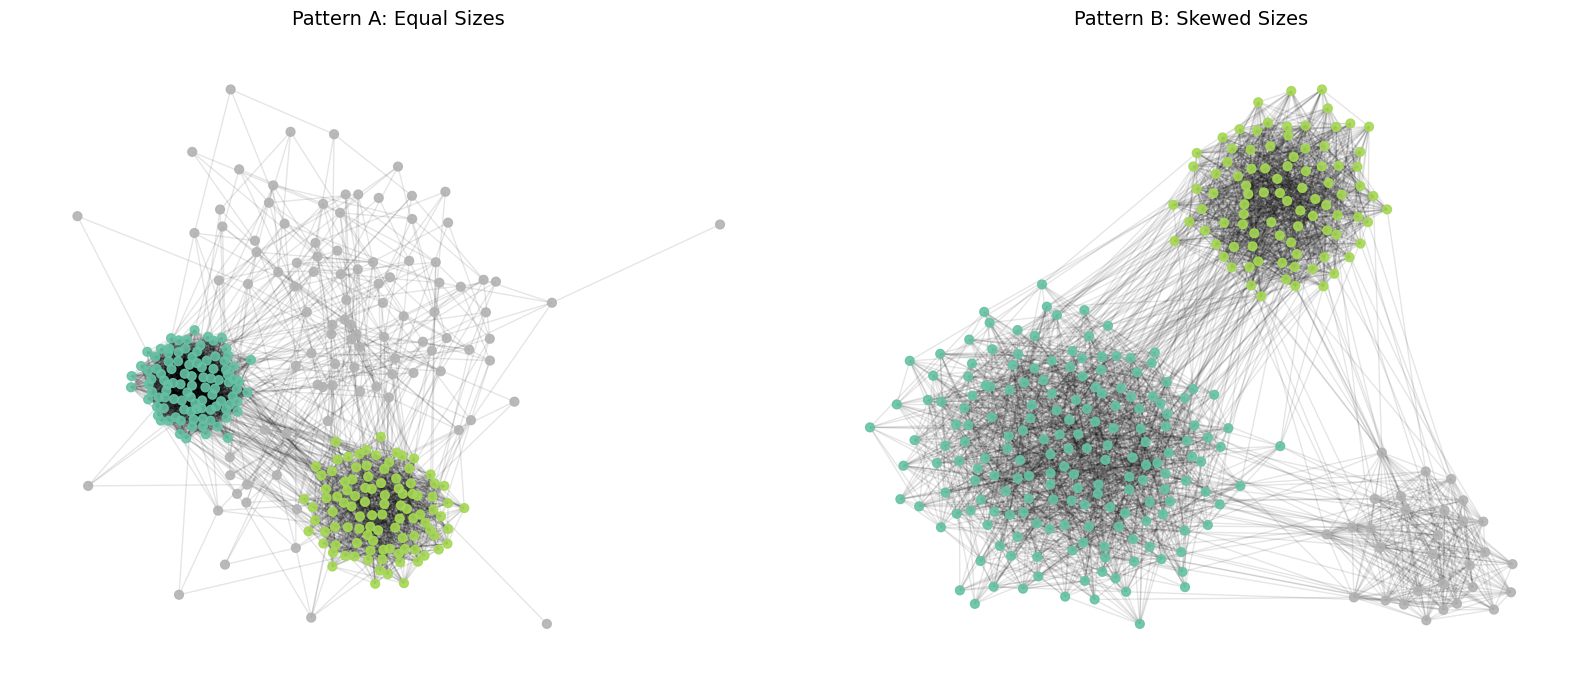

In [67]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. グラフの生成（元のコード＋一部修正）
# ==========================================

# パターンA：規模が同等で、密度が異なる
sizes_equal = [100, 100, 100]  # コミュニティ1, 2, 3のノード数
probs_equal = [
    [0.40, 0.01, 0.01],  # C1の内部密度は 0.40 (密)
    [0.01, 0.20, 0.01],  # C2の内部密度は 0.20 (中)
    [0.01, 0.01, 0.05]   # C3の内部密度は 0.05 (疎)
]
G_sbm_equal = nx.stochastic_block_model(sizes_equal, probs_equal, seed=42)

# パターンB：規模が大中小で、密度も異なる
sizes_skewed = [180, 90, 30]  # 大・中・小のノード数
# 【修正点】対角成分がそれぞれの内部密度になるように修正しました
probs_skewed = [
    [0.10, 0.01, 0.01],  # 大コミュニティはあえて低密度(0.10)に
    [0.01, 0.30, 0.01],  # 中コミュニティは中密度(0.30)に
    [0.01, 0.01, 0.60]   # 小コミュニティは超高密度(0.60)に
]
G_sbm_skewed = nx.stochastic_block_model(sizes_skewed, probs_skewed, seed=42)

# 正解データの確認
print(f"Node 0 in Pattern B belongs to block: {G_sbm_skewed.nodes[0]['block']}")


# ==========================================
# 2. グラフの可視化プログラムを追加
# ==========================================

def draw_sbm_graph(G, ax, title):
    """SBMグラフをコミュニティごとに色分けして描画するヘルパー関数"""
    
    # 各ノードの 'block' 属性（0, 1, 2）を取得し、色分けの基準にする
    node_colors = [G.nodes[n]['block'] for n in G.nodes()]
    
    # spring_layout（ばねモデル）を使用してノード配置を計算
    # kの値を少し小さくすることで、コミュニティのまとまりを視覚的に強調します
    pos = nx.spring_layout(G, k=0.15, seed=42)
    
    # ノードとエッジの描画
    # cmap=plt.cm.Set2 で視認性の高いカラーパレットを使用
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, cmap=plt.cm.Set2, 
                           node_size=40, alpha=0.9, ax=ax)
    # エッジは密集しすぎないように透明度(alpha)を下げて描画
    nx.draw_networkx_edges(G, pos, alpha=0.1, ax=ax)
    
    ax.set_title(title, fontsize=14)
    ax.axis('off')  # 枠線を非表示

# 1つの画面に2つのグラフを並べて表示するための設定
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 各パターンの描画を実行
draw_sbm_graph(G_sbm_equal, axes[0], "Pattern A: Equal Sizes")
draw_sbm_graph(G_sbm_skewed, axes[1], "Pattern B: Skewed Sizes")

plt.tight_layout()
plt.show()